# Does a live mite that looks still give itself away within a recording?

**The hypothesis:** a live mite is never quite still. Even in a recording a person labels still, it breathes, pumps and shifts its weight, too little to see but perhaps enough to measure. The movement score in use asks how *much* the pixels vary over the frames, and for these recordings the answer is the camera's noise. A measurement that asks *how* they vary could find a slow, small movement under that noise: noise has no memory from one frame to the next, a movement does.

**The test:** the long run (`test_run_2026-09-08_Mathis_last_dsRNA`). Four measurements of the order of the variation in time are taken within each recording, and the recordings in which a live mite was labelled still are set against those of dead mites. `alive_dead_overview.ipynb` sets this hypothesis beside the others that were tried.

## Findings (run of 8 October 2026)

One run, one plate, 54 mites that moved at least once.

- **No. A live mite labelled still looks like a dead one within a recording.** The still recordings 20 to 40 recordings before a mite's image stops changing and those in the 40 after it give nearly the same numbers: *order* -0.101 before and -0.102 after, where noise without memory gives -0.100; *trend* 1.01 and 0.99, where noise gives 1.
- **The one measurement that seemed to work measures the clock.** *Order* separates the still recordings of live mites from the dead ones with an AUC of 0.81 pooled and 0.81 within a mite, but 0.66 among the mites of the same recording. At about 20 hours into the run it falls from -0.10 to -0.12 for every mite at once, the ones dead since the first hours included. The live recordings are mostly before that, the dead ones after.
- **Averaging does not rescue it.** Over 6 recordings the pooled AUC rises to 0.95, and the one at the same time stays at 0.75.
- **What changes at 20 hours is on the mites, not in the camera.** The bare plate beside each mite keeps its -0.100 throughout, so the camera's noise is as before. From then on the mites' own pixels swing back and forth from frame to frame a little more than noise would. The movement score of the dead mites rises with it, from 1.57 to 1.63. A shake of the plate that the stabiliser does not take out completely would do that; this notebook does not show what it is.
- **The last hours of a mite are a small exception.** In the 10 recordings before the image stops changing, the recordings labelled still score a little higher on everything (*order* -0.08, movement score 1.6 to 1.8 against 1.5): some of them hold a movement too small to have been labelled.
- **A still mite's movement score is not higher alive than dead; it is lower** (AUC 0.36). Most likely that is the same change at 20 hours, and the brighter plate under the mites that die early (brighter pixels are noisier), not the mites.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "scripts")]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import alive_dead_features as adf
from optuna_death_time import MAX_PAD

# The project's reporting module switches matplotlib to Agg (no figures) on import.
%matplotlib inline

# Chart style, as in death_time_calibration.ipynb: thin marks, recessive axes and grid, text in ink colours.
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8d8c85"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3dc"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "lines.linewidth": 2,
})
COLORS = {"alive": ORANGE, "alive_moving": ORANGE, "alive_still": AQUA, "waiting": GREY, "dead": BLUE}
pd.set_option("display.precision", 3)

run = adf.load_run()
table, images = adf.features(run)   # {feature: (mites, recordings)}, and each mite's mean image per recording
group = adf.groups(run)
n_mites, n_recordings = run.moving.shape
last, moved = run.last, run.moved
step = float(np.median(np.diff(run.times)))  # minutes from one recording to the next
print(f"{run.name}: {n_mites} mites, {n_recordings} recordings {step:g} minutes apart; "
      f"{moved.sum()} mites moved at least once, {(~moved).sum()} never")
print("recordings: " + ", ".join(f"{name} {int(mask.sum())}" for name, mask in group.items()))

  test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings


test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings 10 minutes apart; 54 mites moved at least once, 5 never
recordings: alive 3393, alive_still 2739, alive_moving 651, dead 7191, waiting 5346, never 1475


## The measurements

All are taken from the 10 frames of one recording, over the mite and three pixels around it (`adf.within_features()`). The first is the score in use; the others look at *how* the pixels vary over the frames rather than how much:

- **movement score**: `config.yaml`'s metric and parameters, as an analysis scores it.
- **order**: whether a pixel's deviation from its mean in one frame is followed by a like deviation in the next (lag-1 autocorrelation). The camera's noise has no memory: with 10 frames it gives about -0.1. Something that drifts slowly gives more.
- **trend**: how much of the pixels' variation is a steady drift from the first frame to the last (the F statistic of a straight line; 1 for noise).
- **half change**: the largest differences between the mean of the first 5 frames and of the last 5, after smoothing. Averaging 5 frames takes the noise down, so a slow displacement too small to see in one frame could show.
- **one pattern**: the share of the variation one single pattern of change explains. Noise spreads over as many patterns as there are frames; a leg that moves makes the pixels change together.

Three groups of recordings: **alive, moving** and **alive, still** by the labels (up to the mite's last labelled movement), and **dead** (100 recordings or more after it).

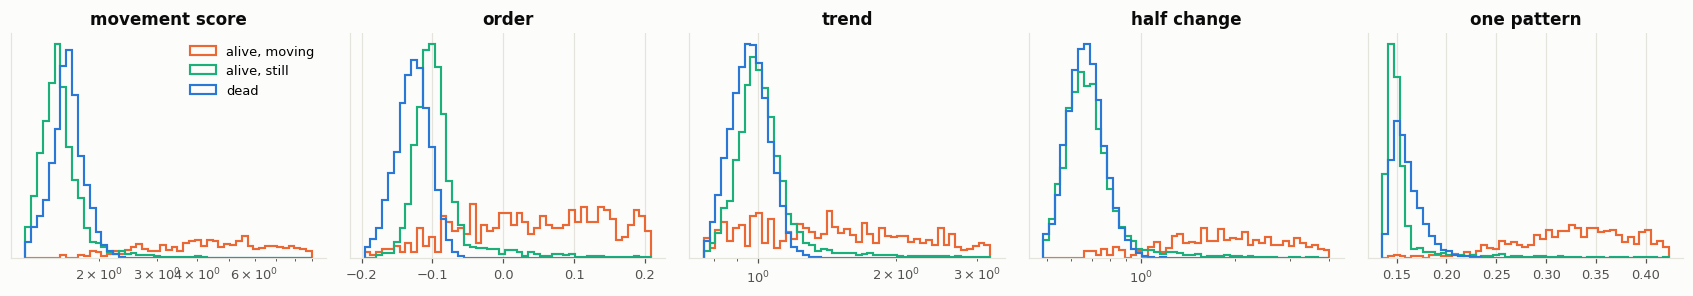

AUC  same time  same mite  distance
measurement    against dead                                        
movement score alive, moving  0.998      1.000      0.994     2.065
               alive, still   0.363      0.337      0.285    -0.623
order          alive, moving  0.938      1.000      0.925     1.968
               alive, still   0.810      0.655      0.812     1.182
trend          alive, moving  0.882      1.000      0.871     1.221
               alive, still   0.653      0.578      0.668     0.489
half change    alive, moving  0.995      1.000      0.994     1.977
               alive, still   0.549      0.512      0.576     0.135
one pattern    alive, moving  0.995      1.000      0.994     3.454
               alive, still   0.305      0.420      0.313    -0.819

In [2]:
within = {"movement score": table["movement_score"], "order": table["order"], "trend": table["trend"],
          "half change": table["half_change"], "one pattern": table["one_pattern"]}
names = {"alive_moving": "alive, moving", "alive_still": "alive, still", "dead": "dead"}

fig, axes = plt.subplots(1, len(within), figsize=(3.1 * len(within), 2.8))
for ax, (name, values) in zip(axes, within.items()):
    low, high = np.percentile(values[group["alive_still"] | group["dead"]], [0.5, 99.5])
    high = max(high, np.percentile(values[group["alive_moving"]], 75))
    logarithmic = name in ("movement score", "trend", "half change")
    bins = np.geomspace(low, high, 50) if logarithmic else np.linspace(low, high, 50)
    for key, label in names.items():
        ax.hist(values[group[key]], bins=bins, density=True, histtype="step", linewidth=1.4, color=COLORS[key], label=label)
    if logarithmic:
        ax.set_xscale("log")
    ax.set_yticks([])
    ax.set_title(name)
axes[0].legend()
plt.tight_layout()
plt.show()

rows = []
for name, values in within.items():
    for positive in ("alive_moving", "alive_still"):
        result = adf.separation(values, group[positive], group["dead"])
        rows.append({"measurement": name, "against dead": names[positive], "AUC": result["auc"], "same time": result["same_time"],
                     "same mite": result["same_mite"], "distance": result["distance"]})
display(pd.DataFrame(rows).set_index(["measurement", "against dead"]))

The three AUCs are explained in `alive_dead_shrinkage.ipynb`. In short: **AUC** pools everything, **same time** compares alive and dead mites within the same recording, **same mite** compares each mite with itself. Only *order* does anything for the still recordings, and its three AUCs do not agree: the pooled one and the one within a mite, which both set early recordings against late ones, are well above the one at the same time.

## The run changes at 20 hours

*Order* by the time into the run, for the mites that were dead through most of it (never labelled moving, or last moved in the first 15 recordings), for the live mites in the recordings they were labelled still, and for the dead ones.

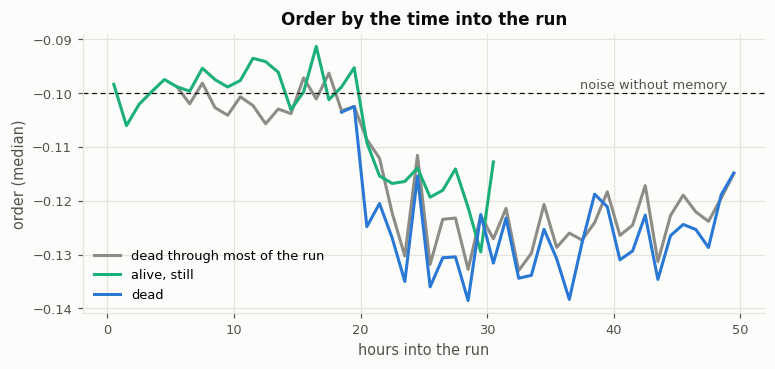

mites dead through most of the run (10): order -0.101 before recording 110, -0.124 from 130 on
recordings 110 to 130: alive, still -0.102 (8 mites), dead -0.110 (15 mites)
recordings 130 to 160: alive, still -0.117 (5 mites), dead -0.128 (32 mites)
recordings 160 to 190: alive, still -0.119 (3 mites), dead -0.130 (42 mites)


In [3]:
order = table["order"]
dead_all_along = (~moved) | (last < 15)
hours = run.times / 60

def by_time(mask, width=6):
    # the median of `order` over the recordings of `mask`, in stretches of `width` recordings; nothing under 10 values
    starts = np.arange(0, n_recordings, width)
    values = [order[:, at:at + width][mask[:, at:at + width]] for at in starts]
    return hours[starts] + width * step / 120, np.array([np.median(v) if len(v) >= 10 else np.nan for v in values])

fig, ax = plt.subplots(figsize=(8, 3.3))
everything = np.ones_like(group["dead"])
ax.plot(*by_time(dead_all_along[:, None] & everything & (np.arange(n_recordings)[None] >= 30)), color=GREY, label="dead through most of the run")
ax.plot(*by_time(group["alive_still"]), color=AQUA, label="alive, still")
ax.plot(*by_time(group["dead"]), color=BLUE, label="dead")
ax.axhline(-1 / 10, color=INK, linewidth=0.8, linestyle=(0, (4, 3)))
ax.annotate("noise without memory", (hours[-1], -0.1), xytext=(0, 3), textcoords="offset points", ha="right", fontsize=8.5, color=MUTED)
ax.set(xlabel="hours into the run", ylabel="order (median)", title="Order by the time into the run")
ax.legend()
plt.show()

early, late = np.arange(n_recordings)[None] < 110, np.arange(n_recordings)[None] >= 130
along = dead_all_along[:, None] & everything
print(f"mites dead through most of the run ({dead_all_along.sum()}): order {np.median(order[along & early & (np.arange(n_recordings)[None] >= 30)]):.3f} "
      f"before recording 110, {np.median(order[along & late]):.3f} from 130 on")
for at_from, at_to in ((110, 130), (130, 160), (160, 190)):
    window = (np.arange(n_recordings)[None] >= at_from) & (np.arange(n_recordings)[None] < at_to)
    print(f"recordings {at_from} to {at_to}: alive, still {np.median(order[group['alive_still'] & window]):.3f} "
          f"({int((group['alive_still'] & window).any(axis=1).sum())} mites), dead {np.median(order[group['dead'] & window]):.3f} "
          f"({int((group['dead'] & window).any(axis=1).sum())} mites)")

What changes there is not the mites. Below, three things of the same recordings that have nothing to do with being alive: the brightness of the plate, the movement score of the mites dead through most of the run, and the *order* of the bare plate at the edge of every mite's patch.

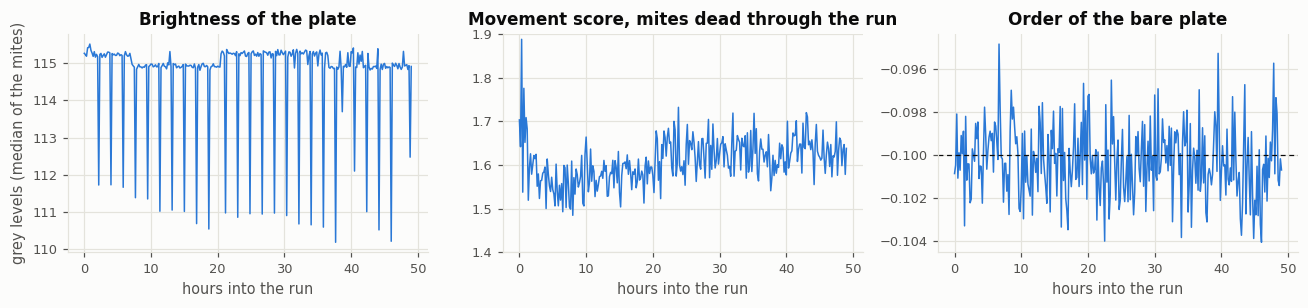

order of the bare plate: -0.100 before recording 110, -0.100 from 130 on
movement score of the mites dead through the run: 1.571 in recordings 30 to 110, 1.633 from 130 on


In [4]:
plate_order = np.zeros((n_mites, n_recordings))
for mite in range(n_mites):
    patches = run.grey(mite)
    frame = adf._frame(patches.shape[-2:], adf.EDGE)
    residual = (patches - patches.mean(axis=1, keepdims=True))[:, :, frame]      # (recordings, frames, pixels)
    plate_order[mite] = (residual[:, 1:] * residual[:, :-1]).sum(axis=(1, 2)) / (residual ** 2).sum(axis=(1, 2))

fig, axes = plt.subplots(1, 3, figsize=(12, 2.9))
axes[0].plot(hours, np.median(table["plate"], axis=0), color=BLUE, linewidth=1)
axes[0].set(title="Brightness of the plate", ylabel="grey levels (median of the mites)")
axes[1].plot(hours, np.median(table["movement_score"][dead_all_along], axis=0), color=BLUE, linewidth=1)
axes[1].set(title="Movement score, mites dead through the run", ylim=(1.4, 1.9))
axes[2].plot(hours, np.median(plate_order, axis=0), color=BLUE, linewidth=1)
axes[2].axhline(-0.1, color=INK, linewidth=0.8, linestyle=(0, (4, 3)))
axes[2].set(title="Order of the bare plate")
for ax in axes:
    ax.set_xlabel("hours into the run")
plt.tight_layout()
plt.show()
print(f"order of the bare plate: {np.median(plate_order[:, :110]):.3f} before recording 110, {np.median(plate_order[:, 130:]):.3f} from 130 on")
print(f"movement score of the mites dead through the run: {np.median(table['movement_score'][dead_all_along][:, 30:110]):.3f} in recordings 30 to 110, "
      f"{np.median(table['movement_score'][dead_all_along][:, 130:]):.3f} from 130 on")

## Would averaging over several recordings help?

A weak sign of life could still be useful if it added up: the mean of *order* over the last *k* recordings, for the stretches in which the mite was alive and labelled still in all *k*, against the stretches in which it was dead in all *k*.

In [5]:
def trailing_mean(values, k):
    total = np.cumsum(np.concatenate([np.zeros((len(values), 1)), values], axis=1), axis=1)
    out = np.full(values.shape, np.nan)
    out[:, k - 1:] = (total[:, k:] - total[:, :-k]) / k
    return out

def throughout(mask, k):
    # the recordings whose last k are all in the mask
    out = mask.copy()
    for back in range(1, k):
        out[:, back:] &= mask[:, :-back]
    out[:, :k - 1] = False
    return out

rows = []
for k in (1, 3, 6, 12):
    result = adf.separation(trailing_mean(order, k), throughout(group["alive_still"], k), throughout(group["dead"], k))
    rows.append({"recordings averaged": k, "stretches alive and still": int(throughout(group["alive_still"], k).sum()),
                 "AUC": result["auc"], "same time": result["same_time"], "same mite": result["same_mite"]})
display(pd.DataFrame(rows).set_index("recordings averaged"))

,stretches alive and still,AUC,same time,same mite
recordings averaged,,,,
1,2739,0.810,0.655,0.812
3,1968,0.918,0.753,0.927
6,1343,0.953,0.753,0.961
12,682,0.971,0.708,0.990


## Around the death

If live mites moved too little to see and stopped when they died, the measurements would step down at the death. They are set here against the **end of change** (the last recording whose image differs from the one before, see `alive_dead_shrinkage.ipynb`), which is closer to the death than the last labelled movement, in the recordings labelled still. Only the mites whose image stopped changing before recording 100 are taken, so that the change of the run at 20 hours stays out of it.

In [6]:
CHANGE_LIMIT = float(np.percentile(table["noise_floor"][run.labelled & ~run.moving], 99.9))
end_of_change = adf.last_change(table["image_change"], CHANGE_LIMIT)
chosen = np.flatnonzero(end_of_change < 100)
since = np.arange(n_recordings)[None] - end_of_change[:, None]
rows = []
for first, end in [(-40, -20), (-20, -10), (-10, -5), (-5, 0), (0, 5), (5, 10), (10, 20), (20, 40)]:
    mask = (since >= first) & (since < end) & ~run.moving & (np.arange(n_recordings)[None] < 110)
    mask[np.setdiff1d(np.arange(n_mites), chosen)] = False
    rows.append({"recordings since the end of change": f"{first} to {end}", "recordings": int(mask.sum()),
                 **{name: np.median(values[mask]) for name, values in within.items()}})
display(pd.DataFrame(rows).set_index("recordings since the end of change"))

,recordings,movement score,order,trend,half change,one pattern
recordings since the end of change,,,,,,
-40 to -20,532,1.501,-0.101,1.013,0.700,0.148
-20 to -10,309,1.564,-0.096,1.031,0.698,0.150
-10 to -5,158,1.760,-0.075,1.109,0.820,0.159
-5 to 0,191,1.594,-0.086,1.082,0.736,0.152
0 to 5,210,1.506,-0.105,0.998,0.664,0.147
5 to 10,210,1.510,-0.102,0.998,0.677,0.147
10 to 20,409,1.499,-0.102,0.988,0.673,0.147
20 to 40,717,1.522,-0.102,0.994,0.667,0.147
